In [4]:
# %%
from __future__ import annotations

from abc import ABC, abstractmethod
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np


In [5]:
# %%
class RegressionLoss(ABC):
    name: str

    @abstractmethod
    def __call__(self, y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
        raise NotImplementedError


@dataclass(frozen=True)
class MSELoss(RegressionLoss):
    name: str = "MSE"

    def __call__(self, y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
        residual = np.subtract(y_pred, y_true)
        return np.square(residual)


@dataclass(frozen=True)
class ArcsinhMSELoss(RegressionLoss):
    epsilon: float = 1e-9
    name: str = "Arcsinh-MSE"

    def __call__(self, y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
        eps = np.maximum(np.float64(self.epsilon), np.finfo(np.float64).tiny)
        y_true_as = np.arcsinh(np.divide(y_true, eps))
        y_pred_as = np.arcsinh(np.divide(y_pred, eps))
        return 0.5 * np.square(np.subtract(y_true_as, y_pred_as))


@dataclass(frozen=True)
class LogModulusMSELoss(RegressionLoss):
    epsilon: float = 1e-9
    name: str = "LogModulus-MSE"

    def __call__(self, y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
        eps = np.maximum(np.float64(self.epsilon), np.finfo(np.float64).tiny)
        y_true_lm = np.sign(y_true) * np.log1p(np.divide(np.abs(y_true), eps))
        y_pred_lm = np.sign(y_pred) * np.log1p(np.divide(np.abs(y_pred), eps))
        return 0.5 * np.square(np.subtract(y_true_lm, y_pred_lm))


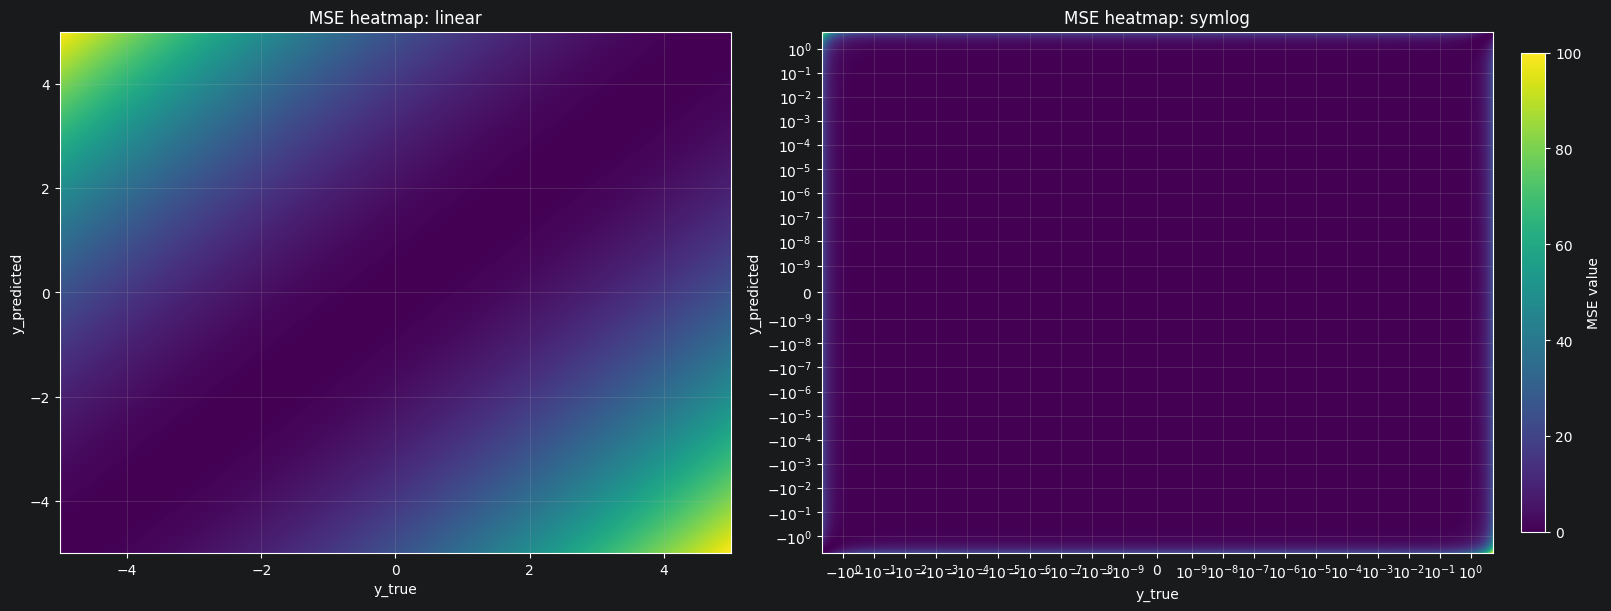

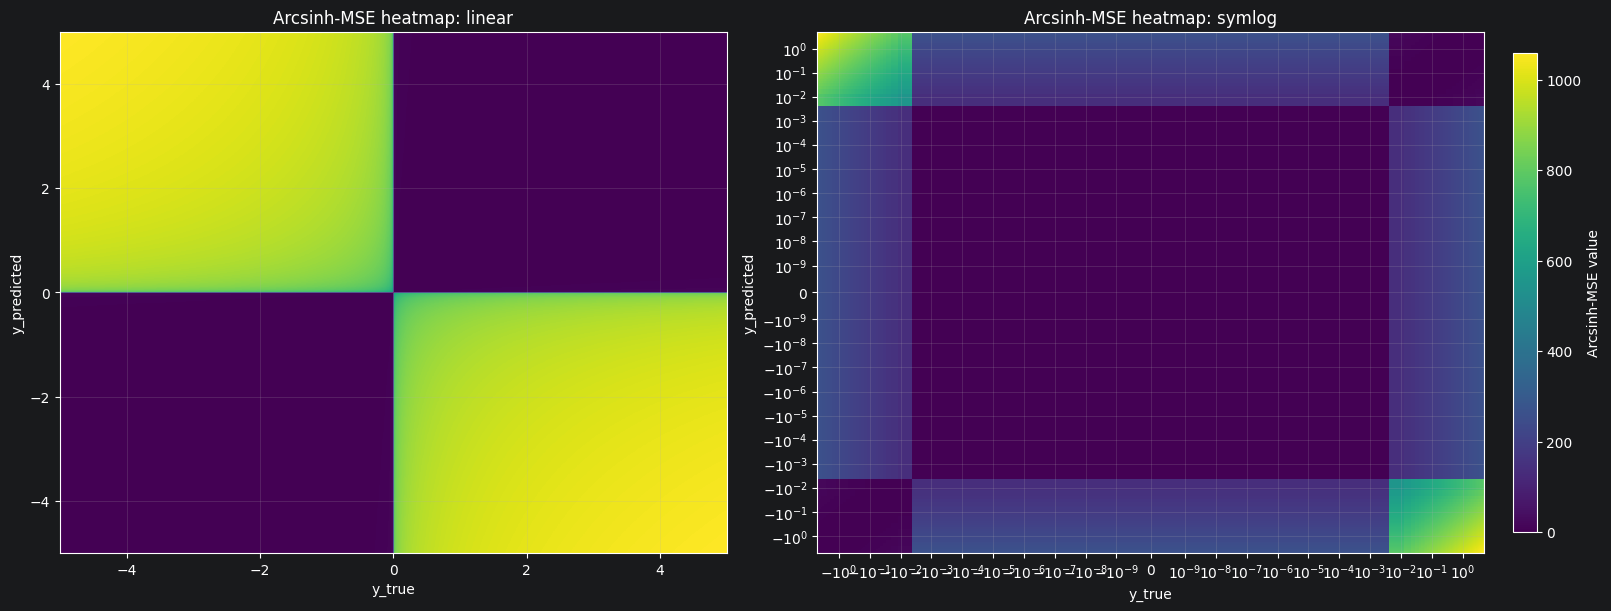

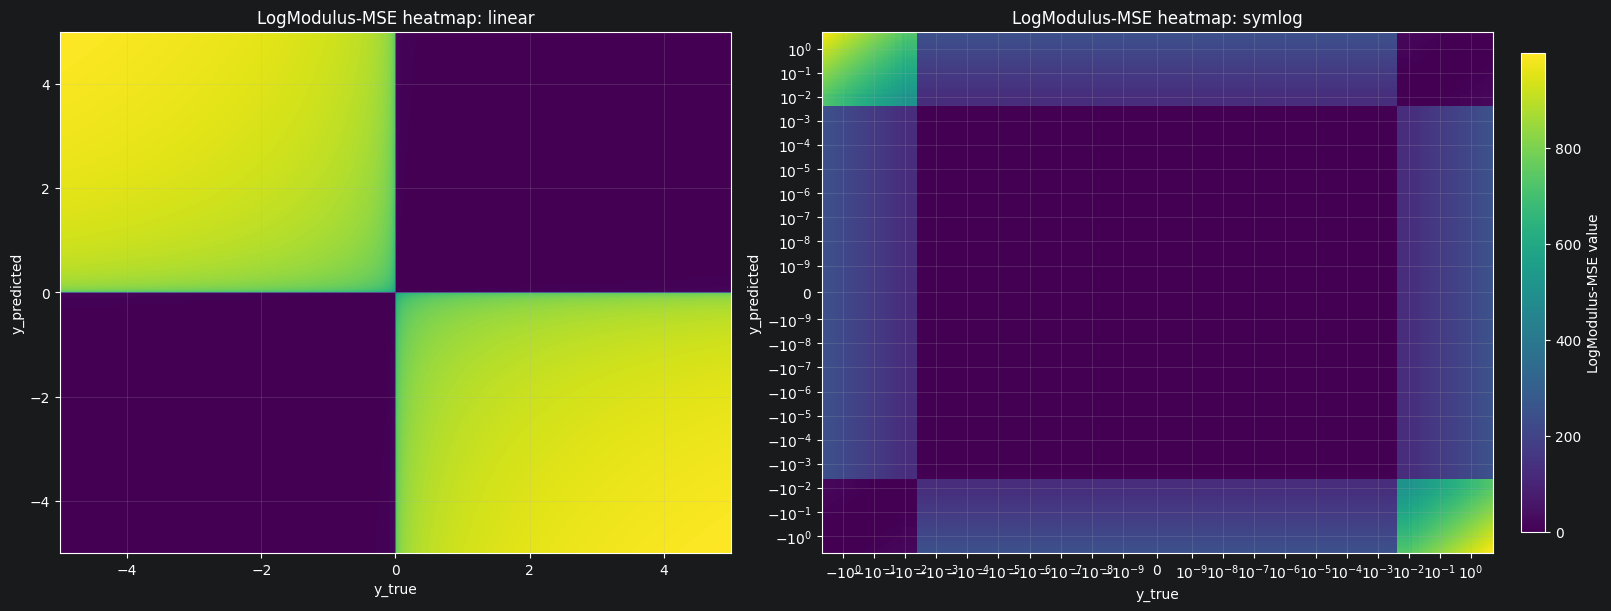

In [6]:
# %%
@dataclass(frozen=True)
class BenchmarkConfig:
    y_min: float = -5.0
    y_max: float = 5.0
    pred_points: int = 1201
    true_points: int = 1201
    cmap_name: str = "viridis"
    symlog_linthresh: float = 1e-9


class LossBenchmark:
    def __init__(self, config: BenchmarkConfig) -> None:
        self.config = config
        self.y_predicted = np.linspace(config.y_min, config.y_max, config.pred_points, dtype=np.float64)
        self.y_true_values = np.linspace(config.y_min, config.y_max, config.true_points, dtype=np.float64)
        self.y_true_grid, self.y_pred_grid = np.meshgrid(self.y_true_values, self.y_predicted, indexing="xy")

    def evaluate(self, loss: RegressionLoss) -> np.ndarray:
        return loss(self.y_true_grid, self.y_pred_grid)

    def plot_heatmap(self, loss: RegressionLoss) -> None:
        loss_values = self.evaluate(loss)
        fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
        vmin = float(np.min(loss_values))
        vmax = float(np.max(loss_values))

        heat_linear = axes[0].pcolormesh(
            self.y_true_grid,
            self.y_pred_grid,
            loss_values,
            shading="auto",
            cmap=self.config.cmap_name,
            vmin=vmin,
            vmax=vmax,
        )
        axes[1].pcolormesh(
            self.y_true_grid,
            self.y_pred_grid,
            loss_values,
            shading="auto",
            cmap=self.config.cmap_name,
            vmin=vmin,
            vmax=vmax,
        )

        axes[0].set_title(f"{loss.name} heatmap: linear")
        axes[0].set_xlabel("y_true")
        axes[0].set_ylabel("y_predicted")
        axes[0].grid(True, which="major", alpha=0.25)

        axes[1].set_title(f"{loss.name} heatmap: symlog")
        axes[1].set_xlabel("y_true")
        axes[1].set_ylabel("y_predicted")
        axes[1].set_xscale("symlog", linthresh=self.config.symlog_linthresh)
        axes[1].set_yscale("symlog", linthresh=self.config.symlog_linthresh)
        axes[1].minorticks_on()
        axes[1].grid(True, which="major", alpha=0.25)
        axes[1].grid(True, which="minor", alpha=0.15)

        cbar = fig.colorbar(heat_linear, ax=axes, orientation="vertical", pad=0.02, shrink=0.92)
        cbar.set_label(f"{loss.name} value")
        plt.show()


config = BenchmarkConfig(y_min=-5.0, y_max=5.0, pred_points=1201, true_points=1201)
benchmark = LossBenchmark(config)

losses = {
    "MSE": MSELoss(),
    "ArcsinhMSE": ArcsinhMSELoss(epsilon=benchmark.config.symlog_linthresh),
    "LogModulusMSE": LogModulusMSELoss(epsilon=benchmark.config.symlog_linthresh),
}

for loss in losses.values():
    _ = benchmark.evaluate(loss)
    benchmark.plot_heatmap(loss)
